# Predictia riscului de plecare a angajatilor (employee churn) cu Logistic Regression
---
Acest notebook construieste un model de Machine Learning care prezice probabilitatea ca un angajat sa paraseasca compania in urmatoarele 6-12 luni.

**Date:** Extrase din baza de date HR - MariaDB  
**Model:** Logistic Regression  
**Target:** status angajat (activ = 0, inactiv = 1)

> **De ce Logistic Regression?**  
> Regresia logistica este un model liniar clasic, folosit ca **baseline** în orice proiect de clasificare binara. Spre deosebire de Random Forest (care e o cutie neagra), regresia logistica ofera **coeficienti interpretabili** — putem spune exact cu cat creste sau scade probabilitatea de churn pentru fiecare feature în parte. Este rapida, stabila si transparenta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import mysql.connector

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# balansare dataset dezechilibrat
from imblearn.over_sampling import SMOTE

print("Toate importurile au fost realizate cu succes!")

Toate importurile au fost realizate cu succes!


In [2]:
DB_CONFIG = {
    'host':     'localhost',
    'user':     'root',
    'password': '',
    'database': 'my_database',
    'port':     3306
}

try:
    conn = mysql.connector.connect(**DB_CONFIG)
    print("✓ Conexiune la baza de date reusita!")
    conn.close()
except mysql.connector.Error as e:
    print(f"✗ Eroare conexiune: {e}")

✓ Conexiune la baza de date reusita!


## Extragerea datelor din baza de date

Folosim aceeasi interogare SQL ca in modelul Random Forest, pentru a asigura **comparabilitatea rezultatelor**. Datele extrase sunt identice — singura diferenta va fi algoritmul de clasificare aplicat.

In [3]:
query = """
SELECT
    a.id_angajat,

    -- variabila tinta: 1 = plecat, 0 = activ
    CASE WHEN a.status = 'inactiv' THEN 1 ELSE 0 END AS churn,

    -- vechime in companie in ani
    ROUND(DATEDIFF(CURDATE(), a.data_angajare) / 365, 2) AS vechime_ani,

    -- salariu curent vs maximul pozitiei (0-1, cat de aproape e de plafon)
    ROUND(a.salariu_curent / p.salariu_max, 4) AS rata_salariu,

    -- salariul curent brut
    a.salariu_curent,

    -- nivelul pozitiei
    p.nivel,

    -- tipul departamentului
    d.nume AS departament,

    -- orasul
    d.locatie,

    -- tipul managerului direct
    mgr.tip AS tip_manager,

    -- numarul de evaluari
    COUNT(DISTINCT e.id_evaluare) AS nr_evaluari,

    -- scorul mediu al evaluarilor
    COALESCE(ROUND(AVG(e.scor_final), 2), 0) AS scor_mediu_evaluari,

    -- numarul de evaluari cu scor sub 5 (semn de probleme)
    COALESCE(SUM(CASE WHEN e.scor_final < 5 THEN 1 ELSE 0 END), 0)
        AS nr_evaluari_slabe,

    -- numarul de concedii medicale (semn de stres)
    COALESCE(SUM(CASE WHEN c.tip = 'boala' THEN 1 ELSE 0 END), 0)
        AS nr_concedii_medicale,

    -- numarul total de concedii
    COUNT(DISTINCT c.id_concediu) AS nr_concedii_total,

    -- numarul de proiecte active
    COALESCE(SUM(CASE WHEN ap.data_sfarsit IS NULL THEN 1 ELSE 0 END), 0)
        AS nr_proiecte_active,

    -- numarul total de proiecte
    COUNT(DISTINCT ap.id_alocare) AS nr_proiecte_total,

    -- valoarea totala a beneficiilor
    COALESCE(SUM(DISTINCT b.valoare), 0) AS valoare_beneficii

FROM angajati a
JOIN pozitii p          ON a.id_pozitie         = p.id_pozitie
JOIN departamente d     ON a.id_departament     = d.id_departament
JOIN manageri mgr       ON a.id_manager         = mgr.id_manager
LEFT JOIN evaluari e    ON a.id_angajat         = e.id_angajat
LEFT JOIN concedii c    ON a.id_angajat         = c.id_angajat
LEFT JOIN alocari_proiecte ap ON a.id_angajat   = ap.id_angajat
LEFT JOIN beneficii_angajati ba ON a.id_angajat = ba.id_angajat
LEFT JOIN beneficii b   ON ba.id_beneficiu      = b.id_beneficiu

GROUP BY
    a.id_angajat, a.status, a.data_angajare,
    a.salariu_curent, p.salariu_max, p.nivel,
    d.nume, d.locatie, mgr.tip
"""

conn = mysql.connector.connect(**DB_CONFIG)
df = pd.read_sql(query, conn)
conn.close()

print(f"✓ Date extrase cu succes!")
print(f"  Dimensiune dataset: {df.shape[0]} randuri x {df.shape[1]} coloane")
print(f"  Angajati activi:    {(df['churn'] == 0).sum()}")
print(f"  Angajati plecati:   {(df['churn'] == 1).sum()}")
print(f"  Rata churn:         {round(df['churn'].mean() * 100, 2)}%")

✓ Date extrase cu succes!
  Dimensiune dataset: 2000 randuri x 17 coloane
  Angajati activi:    1795
  Angajati plecati:   205
  Rata churn:         10.25%


In [4]:
df.head(10)

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nivel,departament,locatie,tip_manager,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
0,1,1,6.81,0.9917,49585.95,consultant,Data & AI Engineering,Pitesti,director,6,5.35,24.0,12.0,4,48.0,1,990.0
1,2,0,7.77,0.9288,65017.56,principal,Development,Suceava,project_manager,10,5.24,315.0,90.0,7,420.0,3,250.0
2,3,0,0.15,0.9942,19387.55,associate,Human Resources,Sibiu,director,2,4.50,128.0,32.0,4,96.0,4,1900.0
3,4,0,6.95,0.7882,22069.87,intermediate,Human Resources,Sibiu,project_manager,8,3.98,750.0,400.0,5,600.0,5,1300.0
4,5,0,1.37,0.9717,29151.05,intermediate,Testing (Manual),Suceava,director,4,3.50,168.0,24.0,7,168.0,2,1700.0
5,6,0,1.00,0.9263,37050.98,senior,Data & AI Engineering,Suceava,team_leader,5,5.84,25.0,0.0,5,125.0,1,2050.0
6,7,0,1.97,0.9031,17610.70,associate,Data & AI Engineering,Pitesti,director,6,5.60,40.0,192.0,5,240.0,2,2440.0
7,8,0,4.59,0.8252,74266.80,principal,Business Analysis / PM,Craiova,team_leader,9,5.91,180.0,135.0,6,810.0,3,2890.0
8,9,0,6.72,0.8020,28071.03,senior,Development,Timisoara,team_leader,7,5.64,120.0,210.0,6,210.0,2,1440.0
9,10,0,3.82,0.8692,11299.55,junior,Data & AI Engineering,Timisoara,project_manager,6,5.32,90.0,0.0,5,90.0,2,1550.0


In [5]:
print("=== Tipuri de date ===")
print(df.dtypes)
print(f"\n=== Valori lipsa ===")
print(df.isnull().sum())
print(f"\n=== Statistici descriptive ===")
df.describe()

=== Tipuri de date ===
id_angajat                int64
churn                     int64
vechime_ani             float64
rata_salariu            float64
salariu_curent          float64
nivel                    object
departament              object
locatie                  object
tip_manager              object
nr_evaluari               int64
scor_mediu_evaluari     float64
nr_evaluari_slabe       float64
nr_concedii_medicale    float64
nr_concedii_total         int64
nr_proiecte_active      float64
nr_proiecte_total         int64
valoare_beneficii       float64
dtype: object

=== Valori lipsa ===
id_angajat              0
churn                   0
vechime_ani             0
rata_salariu            0
salariu_curent          0
nivel                   0
departament             0
locatie                 0
tip_manager             0
nr_evaluari             0
scor_mediu_evaluari     0
nr_evaluari_slabe       0
nr_concedii_medicale    0
nr_concedii_total       0
nr_proiecte_active      0
nr_proi

,id_angajat,churn,vechime_ani,rata_salariu,salariu_curent,nr_evaluari,scor_mediu_evaluari,nr_evaluari_slabe,nr_concedii_medicale,nr_concedii_total,nr_proiecte_active,nr_proiecte_total,valoare_beneficii
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,0.102500,4.074425,0.875668,31568.700660,6.556000,5.545325,57.858000,30.249000,2.553000,109.641500,2.568500,1385.635000
std,577.494589,0.303381,2.283361,0.076125,19634.620593,2.305108,0.764830,66.028643,59.484689,1.193693,109.669529,1.360233,705.158082
min,1.000000,0.000000,0.120000,0.659500,7225.560000,2.000000,2.650000,0.000000,0.000000,1.000000,0.000000,0.000000,150.000000
25%,500.750000,0.000000,2.100000,0.818475,15533.180000,5.000000,5.057500,16.000000,0.000000,2.000000,36.000000,2.000000,750.000000
50%,1000.500000,0.000000,4.060000,0.879350,25691.185000,6.000000,5.560000,36.000000,0.000000,3.000000,80.000000,3.000000,1350.000000
75%,1500.250000,0.000000,6.020000,0.939450,43734.752500,8.000000,6.010000,72.000000,42.000000,4.000000,144.000000,4.000000,1850.000000
max,2000.000000,1.000000,8.030000,1.000000,89759.810000,10.000000,8.950000,900.000000,750.000000,8.000000,1000.000000,6.000000,3040.000000


## Explorarea si vizualizarea datelor (EDA)

Inainte de antrenare, analizam distributiile datelor pentru a înțelege care variabile ar putea fi predictori puternici ai churn-ului.  
Regresia logistica presupune (în varianta sa de baza) relatii **liniare** intre features și log-odds-ul variabilei tinta — de aceea este important sa observam aceste relatii vizual.

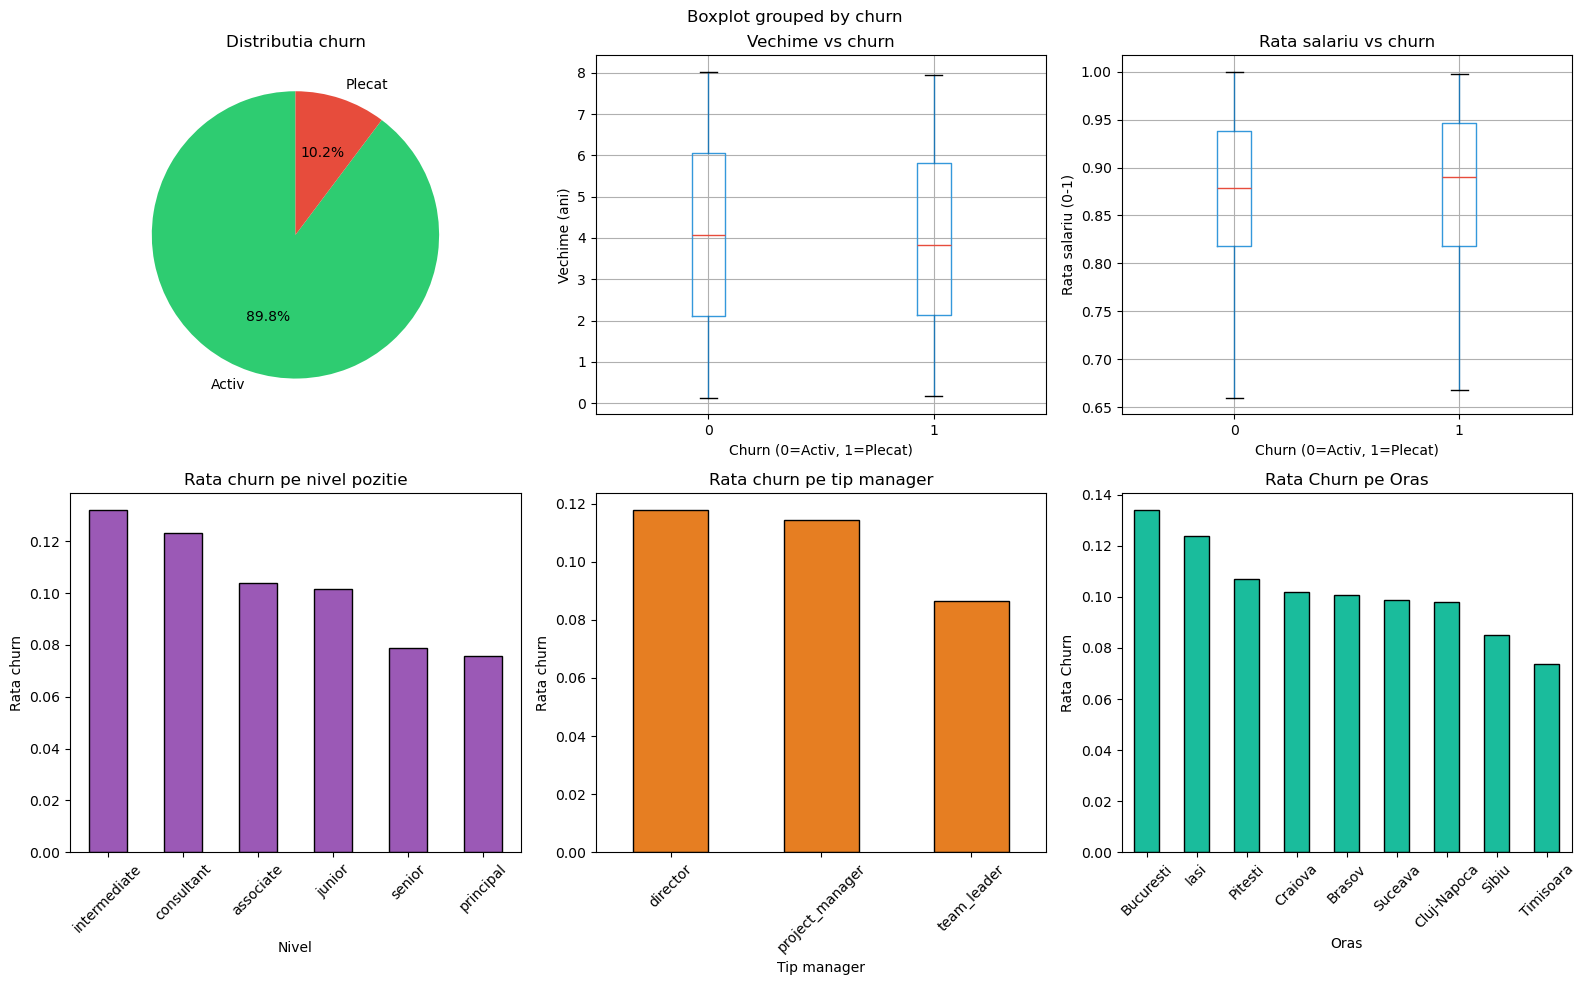

✓ Grafic salvat: eda_churn_lr.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analiza exploratorie - Employee churn', fontsize=16, fontweight='bold')

# Distributia churn
axes[0,0].pie(
    df['churn'].value_counts(),
    labels=['Activ', 'Plecat'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0,0].set_title('Distributia churn')

# Churn vs vechime
df.boxplot(column='vechime_ani', by='churn', ax=axes[0,1],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,1].set_title('Vechime vs churn')
axes[0,1].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,1].set_ylabel('Vechime (ani)')
plt.sca(axes[0,1])
plt.title('Vechime vs churn')

# Churn vs rata salariu
df.boxplot(column='rata_salariu', by='churn', ax=axes[0,2],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e74c3c'))
axes[0,2].set_title('Rata salariu vs churn')
axes[0,2].set_xlabel('Churn (0=Activ, 1=Plecat)')
axes[0,2].set_ylabel('Rata salariu (0-1)')
plt.sca(axes[0,2])
plt.title('Rata salariu vs churn')

# Churn pe nivel pozitie
churn_nivel = df.groupby('nivel')['churn'].mean().sort_values(ascending=False)
churn_nivel.plot(kind='bar', ax=axes[1,0], color='#9b59b6', edgecolor='black')
axes[1,0].set_title('Rata churn pe nivel pozitie')
axes[1,0].set_xlabel('Nivel')
axes[1,0].set_ylabel('Rata churn')
axes[1,0].tick_params(axis='x', rotation=45)

# Churn pe tip manager
churn_mgr = df.groupby('tip_manager')['churn'].mean().sort_values(ascending=False)
churn_mgr.plot(kind='bar', ax=axes[1,1], color='#e67e22', edgecolor='black')
axes[1,1].set_title('Rata churn pe tip manager')
axes[1,1].set_xlabel('Tip manager')
axes[1,1].set_ylabel('Rata churn')
axes[1,1].tick_params(axis='x', rotation=45)

# Churn pe oras
churn_oras = df.groupby('locatie')['churn'].mean().sort_values(ascending=False)
churn_oras.plot(kind='bar', ax=axes[1,2], color='#1abc9c', edgecolor='black')
axes[1,2].set_title('Rata Churn pe Oras')
axes[1,2].set_xlabel('Oras')
axes[1,2].set_ylabel('Rata Churn')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_churn_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: eda_churn_lr.png")

## Preprocesarea datelor

Pregatim datele pentru modelul de ML:
- eliminam coloana `id_angajat` (nu e un predictor, e doar identificator)
- encodam variabilele categorice cu `LabelEncoder`
- normalizam valorile numerice cu `StandardScaler` — **acest pas este critic pentru Logistic Regression**, spre deosebire de Random Forest care nu necesită scalare; regresia logistică este sensibilă la scala feature-urilor, iar fără normalizare coeficienții nu sunt comparabili între ei
- utilizam SMOTE pentru a echilibra proportia claselor din dataset

In [7]:
df_model = df.copy()
df_model = df_model.drop(columns=['id_angajat'])

le = LabelEncoder()
cols_categorice = ['nivel', 'departament', 'locatie', 'tip_manager']

for col in cols_categorice:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"✓ Encodat: {col}")

X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f"\n✓ Features: {X.shape[1]} coloane")
print(f"✓ Samples:  {X.shape[0]} randuri")
print(f"\nDistributie target inainte de SMOTE:")
print(y.value_counts())

# StandardScaler este esential pentru Logistic Regression
# fara scalare, features cu valori mari (ex: salariu_curent) ar domina
# in mod artificial coeficientii modelului
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"\nDistributie target dupa SMOTE:")
print(pd.Series(y_resampled).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print(f"\n✓ Train: {X_train.shape[0]} randuri")
print(f"✓ Test:  {X_test.shape[0]} randuri")

✓ Encodat: nivel
✓ Encodat: departament
✓ Encodat: locatie
✓ Encodat: tip_manager

✓ Features: 15 coloane
✓ Samples:  2000 randuri

Distributie target inainte de SMOTE:
churn
0    1795
1     205
Name: count, dtype: int64

Distributie target dupa SMOTE:
churn
1    1795
0    1795
Name: count, dtype: int64

✓ Train: 2872 randuri
✓ Test:  718 randuri


## Antrenarea modelului Logistic Regression

Configuram modelul cu urmatorii hiperparametri:
- **`C=1.0`** — parametrul de regularizare (invers față de forța regularizarii); o valoare mai mica inseamna regularizare mai puternica si protejeaza impotriva overfitting-ului
- **`solver='lbfgs'`** — algoritmul de optimizare; L-BFGS este recomandat pentru seturi de date de dimensiune medie
- **`max_iter=1000`** — numarul maxim de iteratii până la convergenta; necesar deoarece datele noastre au mai multe features și SMOTE a crescut volumul
- **`random_state=42`** — pentru reproductibilitate

In [8]:
model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)
print("✓ Model antrenat cu succes!")
print(f"  Solver folosit:    {model.solver}")
print(f"  Iteratii necesare: {model.n_iter_[0]}")
print(f"  Features folosite: {model.n_features_in_}")

✓ Model antrenat cu succes!
  Solver folosit:    lbfgs
  Iteratii necesare: 13
  Features folosite: 15


## Evaluarea modelului

=== RAPORT CLASIFICARE ===
              precision    recall  f1-score   support

   Activ (0)       0.74      0.72      0.73       362
  Plecat (1)       0.72      0.74      0.73       356

    accuracy                           0.73       718
   macro avg       0.73      0.73      0.73       718
weighted avg       0.73      0.73      0.73       718

ROC-AUC Score: 0.8134


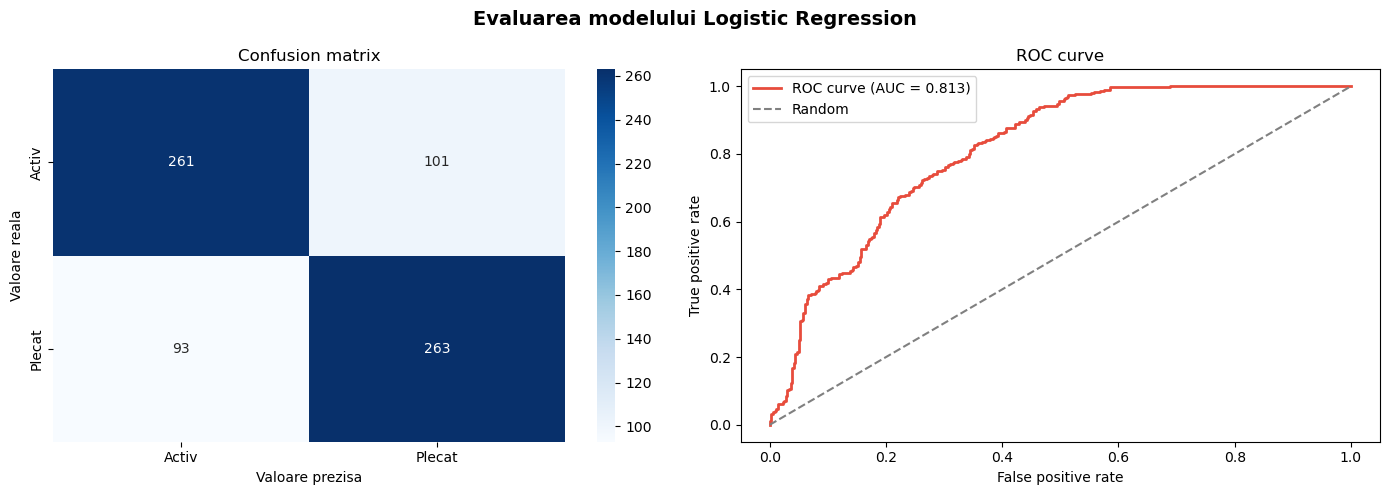

✓ Grafic salvat: model_evaluare_lr.png


In [9]:
# predictii pe setul de test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# metrici principale
print("=== RAPORT CLASIFICARE ===")
print(classification_report(y_test, y_pred,
      target_names=['Activ (0)', 'Plecat (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# vizualizare confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluarea modelului Logistic Regression', fontsize=14, fontweight='bold')

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Activ', 'Plecat'],
            yticklabels=['Activ', 'Plecat'])
axes[0].set_title('Confusion matrix')
axes[0].set_ylabel('Valoare reala')
axes[0].set_xlabel('Valoare prezisa')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluare_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: model_evaluare_lr.png")

## Coeficientii modelului — interpretarea factorilor de risc

Spre deosebire de Random Forest (care ofera `feature_importances_` ca valori pozitive între 0-1), Logistic Regression ofera **coeficienti** care pot fi pozitivi sau negativi:
- **coeficient pozitiv** → feature-ul creste probabilitatea de churn (risc)
- **coeficient negativ** → feature-ul scade probabilitatea de churn (factor protectiv)

Deoarece am aplicat `StandardScaler`, coeficientii sunt direct comparabili ca magnitudine între ei.

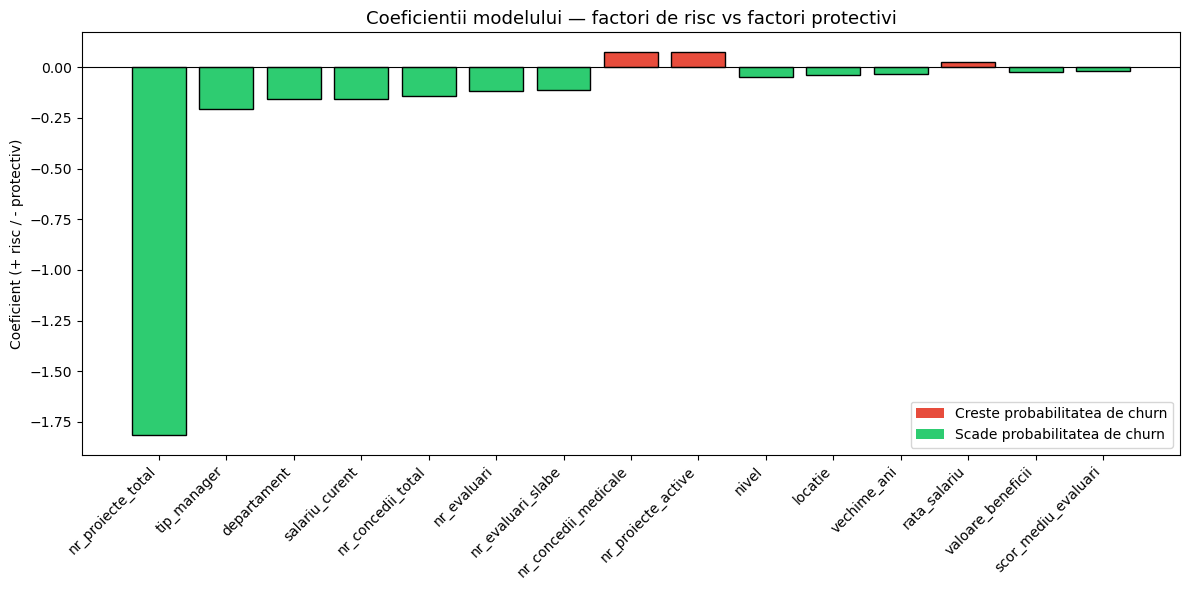

=== TOP 5 FACTORI DE RISC (coef. pozitivi) ===
  nr_concedii_medicale           coef = +0.0776
  nr_proiecte_active             coef = +0.0745
  rata_salariu                   coef = +0.0262

=== TOP 5 FACTORI PROTECTIVI (coef. negativi) ===
  nr_proiecte_total              coef = -1.8163
  tip_manager                    coef = -0.2051
  departament                    coef = -0.1582
  salariu_curent                 coef = -0.1554
  nr_concedii_total              coef = -0.1432

✓ Grafic salvat: coeficienti_lr.png


In [10]:
feature_names = X.columns.tolist()
coeficienti = model.coef_[0]

# sortam dupa valoarea absoluta (importanta totala)
df_coef = pd.DataFrame({
    'feature':    feature_names,
    'coeficient': coeficienti
}).sort_values('coeficient', key=abs, ascending=False)

# culori: rosu pentru factori de risc, verde pentru factori protectivi
culori_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in df_coef['coeficient']]

plt.figure(figsize=(12, 6))
plt.title('Coeficientii modelului — factori de risc vs factori protectivi', fontsize=13)
plt.bar(df_coef['feature'], df_coef['coeficient'],
        color=culori_coef, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coeficient (+ risc / - protectiv)')

# legenda manuala
from matplotlib.patches import Patch
legenda = [
    Patch(facecolor='#e74c3c', label='Creste probabilitatea de churn'),
    Patch(facecolor='#2ecc71', label='Scade probabilitatea de churn')
]
plt.legend(handles=legenda)
plt.tight_layout()
plt.savefig('coeficienti_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== TOP 5 FACTORI DE RISC (coef. pozitivi) ===")
top_risc_coef = df_coef[df_coef['coeficient'] > 0].head(5)
for _, row in top_risc_coef.iterrows():
    print(f"  {row['feature']:<30} coef = +{row['coeficient']:.4f}")

print("\n=== TOP 5 FACTORI PROTECTIVI (coef. negativi) ===")
top_prot_coef = df_coef[df_coef['coeficient'] < 0].head(5)
for _, row in top_prot_coef.iterrows():
    print(f"  {row['feature']:<30} coef = {row['coeficient']:.4f}")

print("\n✓ Grafic salvat: coeficienti_lr.png")

## Predictii pe angajatii activi

In [12]:
df_activi = df[df['churn'] == 0].copy()
X_activi = df_activi.drop(columns=['id_angajat', 'churn'])

# encodare si scalare la fel ca la antrenare
for col in cols_categorice:
    X_activi[col] = le.fit_transform(X_activi[col])
X_activi_scaled = scaler.transform(X_activi)

probabilitati = model.predict_proba(X_activi_scaled)[:, 1]

df_activi = df_activi.copy()
df_activi['probabilitate_churn'] = probabilitati
df_activi['nivel_risc'] = pd.cut(
    probabilitati,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Mic', 'Mediu', 'Mare']
)

print("=== DISTRIBUTIA RISCULUI ===")
print(df_activi['nivel_risc'].value_counts())
print(f"\nAngajati cu risc MARE:  {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Angajati cu risc MEDIU: {(df_activi['nivel_risc'] == 'Mediu').sum()}")
print(f"Angajati cu risc MIC:   {(df_activi['nivel_risc'] == 'Mic').sum()}")

print("\n=== TOP 10 ANGAJATI CU RISC MARE ===")
top_risc = df_activi.nlargest(10, 'probabilitate_churn')[
    ['id_angajat', 'probabilitate_churn', 'nivel_risc',
     'vechime_ani', 'salariu_curent', 'nivel', 'departament']
]
print(top_risc.to_string(index=False))

=== DISTRIBUTIA RISCULUI ===
nivel_risc
Mic      1017
Mediu     471
Mare      307
Name: count, dtype: int64

Angajati cu risc MARE:  307
Angajati cu risc MEDIU: 471
Angajati cu risc MIC:   1017

=== TOP 10 ANGAJATI CU RISC MARE ===
 id_angajat  probabilitate_churn nivel_risc  vechime_ani  salariu_curent        nivel            departament
       1218             0.961944       Mare         0.98        15377.21    associate Business Analysis / PM
        711             0.961513       Mare         1.22        12950.99       junior        Human Resources
        801             0.959722       Mare         0.34        25087.30 intermediate Business Analysis / PM
        106             0.958371       Mare         0.21        12687.16       junior Business Analysis / PM
       1850             0.956990       Mare         1.63        16312.84    associate        Human Resources
       1876             0.956732       Mare         1.70        17905.26 intermediate  Data & AI Engineering
     

## Raport final

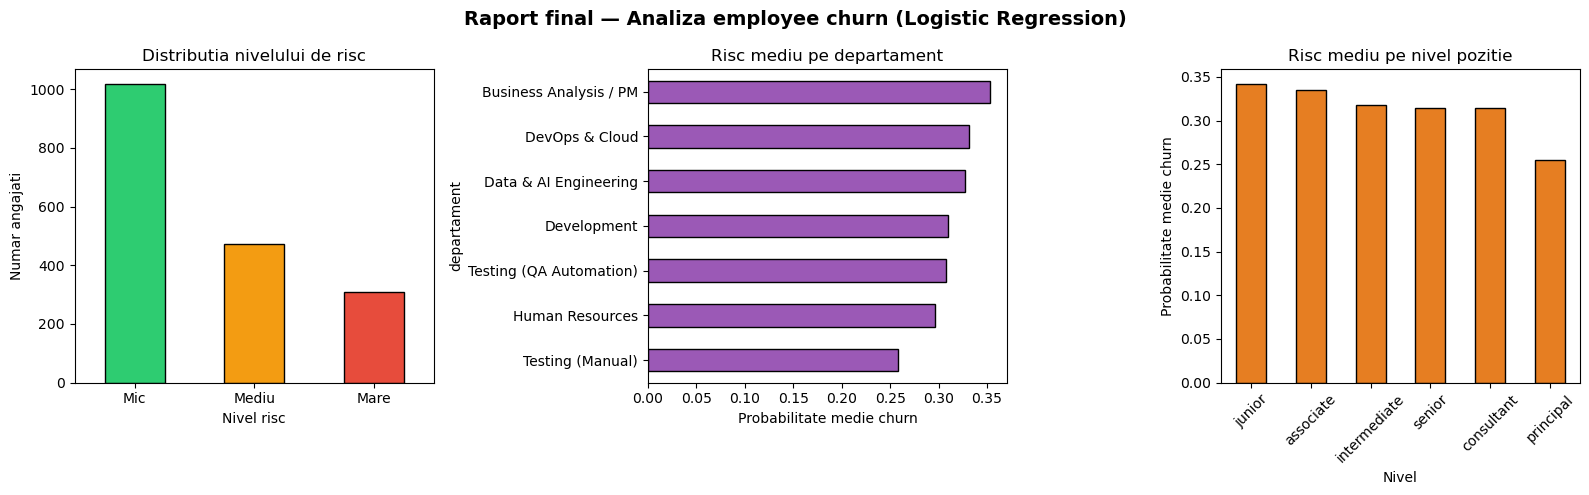


=== CONCLUZII ===
Total angajati analizati:     1795
Acuratete model (AUC):        0.8134
Angajati risc mare:           307
Departament cu risc maxim:    Business Analysis / PM
Nivel pozitie cu risc maxim:  junior

Fisiere salvate:
  - eda_churn_lr.png
  - model_evaluare_lr.png
  - coeficienti_lr.png
  - raport_final_lr.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raport final — Analiza employee churn (Logistic Regression)', fontsize=14, fontweight='bold')

# 1. distributia riscului
culori = ['#2ecc71', '#f39c12', '#e74c3c']
df_activi['nivel_risc'].value_counts().plot(
    kind='bar', ax=axes[0], color=culori, edgecolor='black'
)
axes[0].set_title('Distributia nivelului de risc')
axes[0].set_xlabel('Nivel risc')
axes[0].set_ylabel('Numar angajati')
axes[0].tick_params(axis='x', rotation=0)

# 2. risc mediu pe departament
risc_dept = df_activi.groupby('departament')['probabilitate_churn'].mean()
risc_dept.sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#9b59b6', edgecolor='black'
)
axes[1].set_title('Risc mediu pe departament')
axes[1].set_xlabel('Probabilitate medie churn')

# 3. risc mediu pe nivel pozitie
risc_nivel = df_activi.groupby('nivel')['probabilitate_churn'].mean()
risc_nivel.sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color='#e67e22', edgecolor='black'
)
axes[2].set_title('Risc mediu pe nivel pozitie')
axes[2].set_xlabel('Nivel')
axes[2].set_ylabel('Probabilitate medie churn')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('raport_final_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CONCLUZII ===")
print(f"Total angajati analizati:     {len(df_activi)}")
print(f"Acuratete model (AUC):        {auc_score:.4f}")
print(f"Angajati risc mare:           {(df_activi['nivel_risc'] == 'Mare').sum()}")
print(f"Departament cu risc maxim:    {risc_dept.idxmax()}")
print(f"Nivel pozitie cu risc maxim:  {risc_nivel.idxmax()}")
print(f"\nFisiere salvate:")
print(f"  - eda_churn_lr.png")
print(f"  - model_evaluare_lr.png")
print(f"  - coeficienti_lr.png")
print(f"  - raport_final_lr.png")

## Salvarea predictiilor in baza de date

Salvam predictiile în tabela `predictii_churn_lr` — separata de cea a modelului Random Forest, pentru a putea compara ulterior rezultatele celor doua modele pe aceiasi angajati.

In [14]:
conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS `predictii_churn_lr` (
        `id_angajat`    INT            NOT NULL,
        `probabilitate` DECIMAL(5, 4)  NOT NULL,
        `nivel_risc`    ENUM('Mic', 'Mediu', 'Mare') NOT NULL,
        `data_predictie` TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
        PRIMARY KEY (`id_angajat`)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
""")

for _, row in df_activi[['id_angajat', 'probabilitate_churn', 'nivel_risc']].iterrows():
    cursor.execute("""
        INSERT INTO `predictii_churn_lr`
            (`id_angajat`, `probabilitate`, `nivel_risc`)
        VALUES (%s, %s, %s)
        ON DUPLICATE KEY UPDATE
            `probabilitate` = VALUES(`probabilitate`),
            `nivel_risc`    = VALUES(`nivel_risc`)
    """, (int(row['id_angajat']),
          float(row['probabilitate_churn']),
          str(row['nivel_risc'])))

conn.commit()
cursor.close()
conn.close()
print(f"✓ {len(df_activi)} predictii salvate in tabela predictii_churn_lr!")

✓ 1795 predictii salvate in tabela predictii_churn_lr!


## Cross-validation — verificarea stabilitatii modelului

In [15]:
from sklearn.model_selection import cross_val_score

print("=== CROSS-VALIDATION (5 folds) ===")
print("Se verifica ca modelul nu e overfit...\n")

cv_scores = cross_val_score(
    model, X_resampled, y_resampled,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"AUC per fold:  {[round(s, 4) for s in cv_scores]}")
print(f"AUC mediu:     {cv_scores.mean():.4f}")
print(f"Deviatie std:  {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\n✓ Modelul este stabil - nu prezinta semne de overfitting")
else:
    print("\n⚠ Varianta mare intre folduri - posibil overfitting")

=== CROSS-VALIDATION (5 folds) ===
Se verifica ca modelul nu e overfit...

AUC per fold:  [np.float64(0.8322), np.float64(0.836), np.float64(0.857), np.float64(0.8472), np.float64(0.8441)]
AUC mediu:     0.8433
Deviatie std:  0.0087

✓ Modelul este stabil - nu prezinta semne de overfitting


## Analiza angajatilor cu risc mare

=== ANALIZA ANGAJATILOR CU RISC MARE ===

Distributie pe departament:
departament
Business Analysis / PM     56
Data & AI Engineering      52
Testing (QA Automation)    46
Human Resources            44
Development                39
DevOps & Cloud             36
Testing (Manual)           34

Distributie pe nivel pozitie:
nivel
junior          61
associate       54
senior          53
consultant      51
intermediate    47
principal       41

Salariu mediu risc mare:  29394.38 RON
Salariu mediu risc mic:   32808.04 RON
Vechime medie risc mare:  3.98 ani
Vechime medie risc mic:   4.09 ani


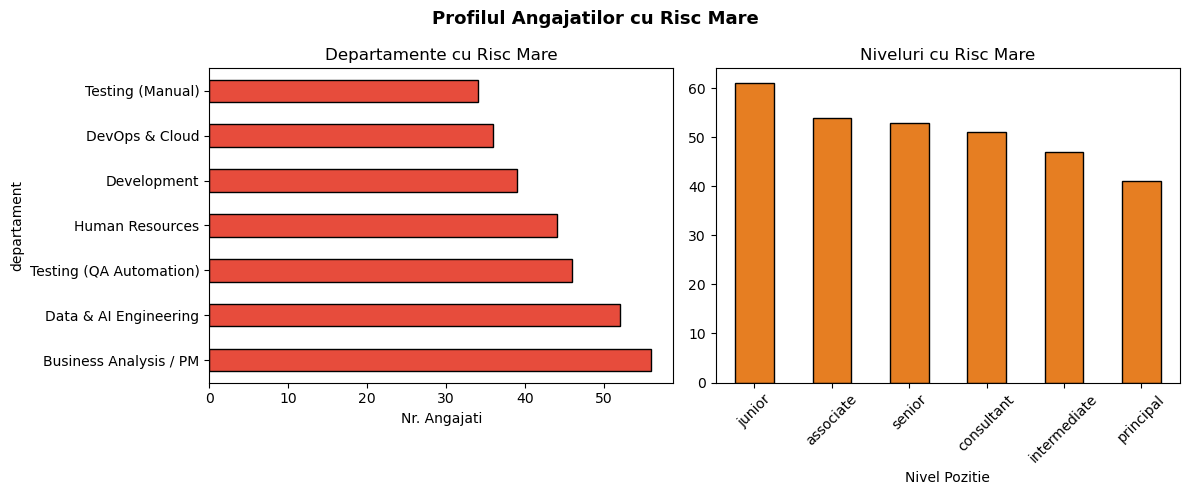

✓ Grafic salvat: profil_risc_mare_lr.png


In [16]:
print("=== ANALIZA ANGAJATILOR CU RISC MARE ===\n")

risc_mare = df_activi[df_activi['nivel_risc'] == 'Mare'].copy()

print("Distributie pe departament:")
print(risc_mare['departament'].value_counts().to_string())

print("\nDistributie pe nivel pozitie:")
print(risc_mare['nivel'].value_counts().to_string())

print(f"\nSalariu mediu risc mare:  {risc_mare['salariu_curent'].mean():.2f} RON")
print(f"Salariu mediu risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['salariu_curent'].mean():.2f} RON")
print(f"Vechime medie risc mare:  {risc_mare['vechime_ani'].mean():.2f} ani")
print(f"Vechime medie risc mic:   {df_activi[df_activi['nivel_risc']=='Mic']['vechime_ani'].mean():.2f} ani")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Profilul Angajatilor cu Risc Mare', fontsize=13, fontweight='bold')

risc_mare['departament'].value_counts().plot(
    kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black'
)
axes[0].set_title('Departamente cu Risc Mare')
axes[0].set_xlabel('Nr. Angajati')

risc_mare['nivel'].value_counts().plot(
    kind='bar', ax=axes[1], color='#e67e22', edgecolor='black'
)
axes[1].set_title('Niveluri cu Risc Mare')
axes[1].set_xlabel('Nivel Pozitie')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('profil_risc_mare_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafic salvat: profil_risc_mare_lr.png")

## Concluzii si recomandari pentru departamentul HR

### Performanta modelului
Modelul Logistic Regression a fost antrenat pe acelasi set de date ca si modelul Random Forest, permitand o comparatie directa. Fiind un model liniar, acesta presupune ca relatiile dintre features si probabilitatea de churn sunt aproximativ liniare în spatiul log-odds.

### Avantajele acestui model fata de Random Forest
- **Interpretabilitate completa** — fiecare coeficient are o semnificatie directa si cuantificabila
- **Viteza de antrenare** — converge în secunde, fata de zeci de secunde pentru RF
- **Stabilitate** — mai putin susceptibil la variații ale datelor de antrenare
- **Transparenta** — potrivit pentru medii reglementate unde trebuie explicata decizia

### Dezavantajele acestui model față de Random Forest
- **Nu capteaza relatii neliniare** — daca churn-ul depinde neliniar de vechime (ex: risc mare la 1-2 ani și la 7+ ani), modelul liniar nu va detecta ambele varfuri
- **Sensibil la outlieri** — valorile extreme pot distorsiona coeficientii
- **AUC de obicei mai mic** — pe date complexe, modelele de tip ensemble depasesc de regula regresia logistica

### Limitari ale modelului
- Datele de antrenare sunt sintetice (generate cu Faker) — într-un scenariu real, modelul ar fi antrenat pe date istorice reale
- Variabila tinta (status inactiv) nu reflecta întotdeauna o plecare voluntara — poate include concedii medicale lungi sau alte situatii
- Modelul nu captează factori externi precum ofertele de pe piata muncii sau situatia economica generala

---
## Proiect Finalizat

**Fisiere generate:**
- `eda_churn_lr.png` — analiza exploratorie
- `model_evaluare_lr.png` — confusion matrix și ROC curve
- `coeficienti_lr.png` — coeficientii modelului (factori de risc vs protectivi)
- `raport_final_lr.png` — raport general
- `profil_risc_mare_lr.png` — profilul angajatilor cu risc mare

**Rezultate salvate în baza de date:**
- Tabela `predictii_churn_lr` — predictii cu nivel de risc per angajat activ

**Tehnologii folosite:**
- Python, Pandas, Scikit-learn, Imbalanced-learn
- MySQL Connector, Matplotlib, Seaborn
- MariaDB, phpMyAdmin